In [1]:
%matplotlib ipympl

from ipywidgets import *

import sys
from time import time
import itertools
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colormaps
from mpl_toolkits.mplot3d import Axes3D, art3d

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 75

import xml.etree.ElementTree as ET
import h5py

from importlib import reload

import gvar as gv

sys.path.append('/Users/patrickoare/lqcd/utilities')
# import pytools as pyt
import plottools as pt
import formattools as fmt
pt.set_font()
default_style = fmt.styles['notebook']
default_style['colwidth'] = 12

import GCR
import utils

In [2]:
# s = 'Level 1 PGCR step[9]  resid 47.3854163 target 2.5165824e-09'
# header = 'Level 1 PGCR step['
# float(s.split(header)[1].split('resid ')[1].split(' target')[0])

### Valence $m=0.01$

In [3]:
def parse_log(file, header = 'Level 1 PGCR step[', split_token = 'Fine Grid Smoother -- Level 2'):
    run = -1
    tokens = [x.strip() for x in file.split('\n')]
    resids = [[], []]           # [[Cheby resids], [KS resids]]
    with open(file) as f:
        lines = f.readlines()
        for token in lines:
            if split_token in token:
                run += 1
            if run < 0 or header not in token:
                continue
            resid = float(token.split('[')[1].split('resid ')[1].split(' target')[0])
            resids[run].append(resid)
    return resids

In [4]:
cheby_10, ks_10 = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_333941.log')
cg_20, ks_20 = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_334415.log')
cg_40, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_335010.log')
gcr_20, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_335405.log')
hdcg_40, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_335553.log')
gcr_40, ks_40 = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_337852.log')

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/4q/v1ykxzz94sn6ms0kkh0gm8880000gr/T/ipykernel_32917/2067105753.py:4: SyntaxWarning: invalid escape sequence '\d'
  pt.scatter_1d(np.arange(len(cg_20)) + 1, cg_20, ax = ax, col = pt.pal[0], ax_label = ['Iteration', 'Residual'], fn_label = '$M^\dagger M$ i.i. (20)')


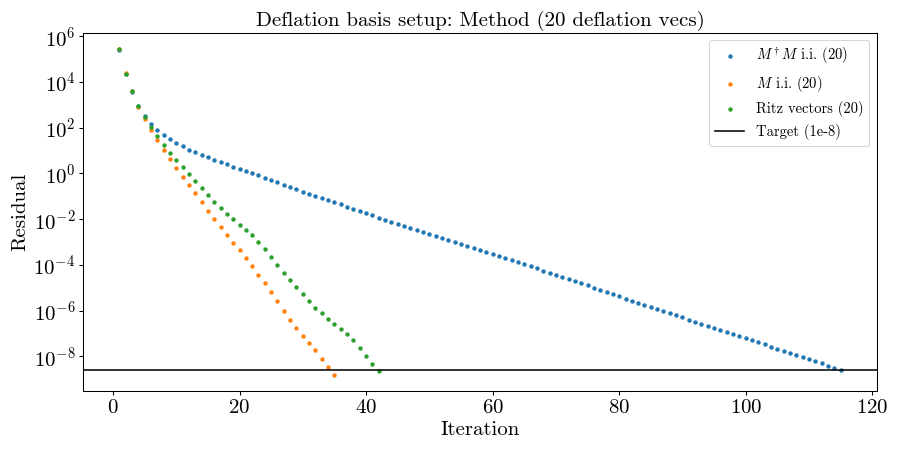

In [5]:
# i.i. = inverse iteration
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.arange(len(cg_20)) + 1, cg_20, ax = ax, col = pt.pal[0], ax_label = ['Iteration', 'Residual'], fn_label = '$M^\dagger M$ i.i. (20)')
pt.scatter_1d(np.arange(len(gcr_20)) + 1, gcr_20, ax = ax, col = pt.pal[1], ax_label = ['Iteration', 'Residual'], fn_label = '$M$ i.i. (20)')
pt.scatter_1d(np.arange(len(ks_20)) + 1, ks_20, ax = ax, col = pt.pal[2], ax_label = ['Iteration', 'Residual'], fn_label = 'Ritz vectors (20)')

pt.add_line(ax, val = 2.5165824e-09, c = 'k', orientation = 'h', label = 'Target (1e-8)')

ax.set_title('Deflation basis setup: Method (20 deflation vecs)', fontsize = default_style['fontsize'])
ax.set_yscale('log')
ax.legend(fontsize = default_style['fontsize'] * 0.7, bbox_to_anchor = (1, 1))
plt.tight_layout()

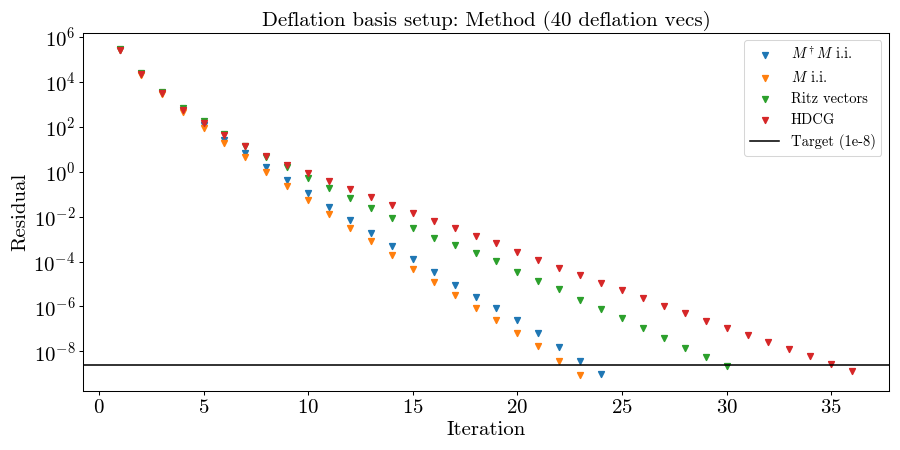

In [6]:
fig, axes = pt.add_subplots()
ax = axes[0]

pt.scatter_1d(np.arange(len(cg_40)) + 1, cg_40, ax = ax, col = pt.pal[0], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = r'$M^\dagger M$ i.i.')
pt.scatter_1d(np.arange(len(gcr_40)) + 1, gcr_40, ax = ax, col = pt.pal[1], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = r'$M$ i.i.')
pt.scatter_1d(np.arange(len(ks_40)) + 1, ks_40, ax = ax, col = pt.pal[2], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = 'Ritz vectors')
pt.scatter_1d(np.arange(len(hdcg_40)) + 1, hdcg_40, ax = ax, col = pt.pal[3], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = 'HDCG')

pt.add_line(ax, val = 2.5165824e-09, c = 'k', orientation = 'h', label = 'Target (1e-8)')

ax.set_title('Deflation basis setup: Method (40 deflation vecs)', fontsize = default_style['fontsize'])
ax.set_yscale('log')
ax.legend(fontsize = default_style['fontsize'] * 0.7, bbox_to_anchor = (1, 1))
plt.tight_layout()

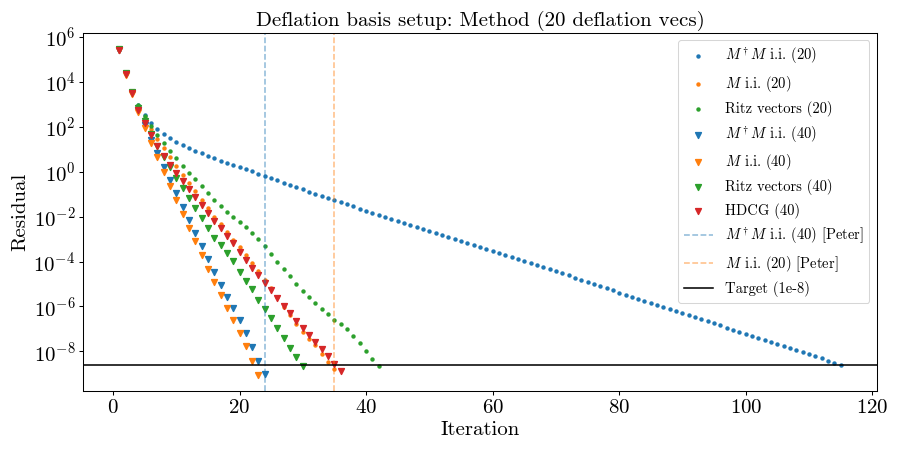

In [7]:
fig, axes = pt.add_subplots()
ax = axes[0]

pt.scatter_1d(np.arange(len(cg_20)) + 1, cg_20, ax = ax, col = pt.pal[0], ax_label = ['Iteration', 'Residual'], fn_label = r'$M^\dagger M$ i.i. (20)')
pt.scatter_1d(np.arange(len(gcr_20)) + 1, gcr_20, ax = ax, col = pt.pal[1], ax_label = ['Iteration', 'Residual'], fn_label = r'$M$ i.i. (20)')
pt.scatter_1d(np.arange(len(ks_20)) + 1, ks_20, ax = ax, col = pt.pal[2], ax_label = ['Iteration', 'Residual'], fn_label = 'Ritz vectors (20)')

pt.scatter_1d(np.arange(len(cg_40)) + 1, cg_40, ax = ax, col = pt.pal[0], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = r'$M^\dagger M$ i.i. (40)')
pt.scatter_1d(np.arange(len(gcr_40)) + 1, gcr_40, ax = ax, col = pt.pal[1], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = r'$M$ i.i. (40)')
pt.scatter_1d(np.arange(len(ks_40)) + 1, ks_40, ax = ax, col = pt.pal[2], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = 'Ritz vectors (40)')
pt.scatter_1d(np.arange(len(hdcg_40)) + 1, hdcg_40, ax = ax, col = pt.pal[3], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = 'HDCG (40)')

pt.add_line(ax, val = 24, c = pt.pal[0], alpha = 0.5, linestyle = '--', label = r'$M^\dagger M$ i.i. (40) [Peter]')
# pt.add_line(ax, val = 35, c = pt.pal[1], alpha = 0.5, linestyle = '--', label = r'$M$ i.i. (20), HDCG(40) [Peter]')
pt.add_line(ax, val = 35, c = pt.pal[1], alpha = 0.5, linestyle = '--', label = r'$M$ i.i. (20) [Peter]')

pt.add_line(ax, val = 2.5165824e-09, c = 'k', orientation = 'h', label = 'Target (1e-8)')

ax.set_title('Deflation basis setup: Method (20 deflation vecs)', fontsize = default_style['fontsize'])
ax.set_yscale('log')
ax.legend(fontsize = default_style['fontsize'] * 0.7, bbox_to_anchor = (1, 1))
plt.tight_layout()

### Spectrum

In [8]:
def parse_output(estr):
    tokens = [x.strip() for x in estr.split('\n')]
    evals = []
    for token in tokens:
        if token == '': continue
        assert token[0] == '(' and token[-1] == ')', 'Wrong token input'
        token = token[1:-1].split(',')              # token == ['re', 'im']
        evals.append(
            float(token[0]) + 1j*float(token[1])
        )
    return evals

In [9]:
pvdavm_evals = parse_output(r"""(0.00783777644,-2.18696589e-14)
 (0.00793712024,-0.00233563953)
  (0.00793712024,0.00233563953)
   (0.0079192746,0.00612062822)
  (0.0079192746,-0.00612062822)
  (0.00824646982,-0.0109907841)
   (0.00824646982,0.0109907841)
  (0.00861008307,-0.0122992181)
   (0.00861008307,0.0122992181)
    (0.00908786589,0.013649063)
   (0.00908786589,-0.013649063)
   (0.00901549137,0.0164975382)
  (0.00901549137,-0.0164975382)
  (0.00971712678,-0.0188641122)
   (0.00971712678,0.0188641122)
    (0.00932132839,-0.01917476)
     (0.00932132839,0.01917476)
   (0.0102084712,-0.0235018747)
    (0.0102084712,0.0235018747)
   (0.0101329536,-0.0243512003)
    (0.0101329536,0.0243512003)
    (0.0102828837,0.0251284544)
   (0.0102828837,-0.0251284544)
   (0.0106283517,-0.0279886586)
    (0.0106283517,0.0279886586)
     (0.0112557275,0.030825775)
    (0.0112557275,-0.030825775)
    (0.0121956012,0.0326433484)
   (0.0121946283,-0.0326450148)
   (0.0120972679,-0.0346510587)
    (0.0120972679,0.0346510587)
    (0.0132730519,0.0369533095)
   (0.0134104205,-0.0376077379)
    (0.0138048991,0.0400715052)
   (0.0138049731,-0.0400715091)
    (0.0145038971,0.0422109975)
   (0.0162247497,-0.0487128771)
    (0.0162248333,0.0487129126)
   (0.0185350722,-0.0561018352)
    (0.0185350813,0.0561018378)""")

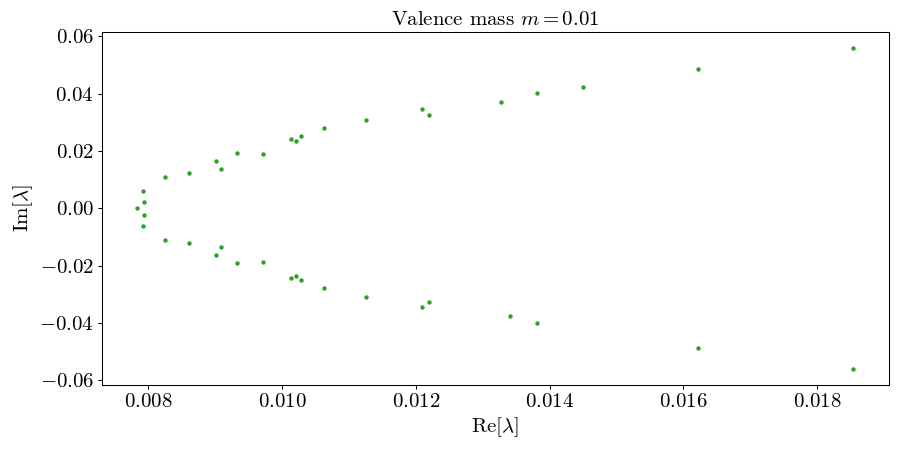

In [10]:
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(pvdavm_evals), np.imag(pvdavm_evals), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], title = r'Valence mass $m=0.01$', fn_label = r'$PV^\dagger M$')
# pt.add_line(ax, np.real(pvdavm_evals[20]), c = pt.pal[2], linestyle = '--')
# ax.legend(title = r'# evals', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
plt.tight_layout()
# pt.save_figure('/Users/patrickoare/Dropbox (Personal)/research/multigrid/columbia_seminar/pvdagm_spectra.pdf')

In [11]:
# read off nulliness for GCR
def read_nulliness(file, splitter = '<i|D|i>=', second_split = '; <i|DdagD|i>='):
    tokens = [x.strip() for x in file.split('\n')]
    nulliness = [[], []]           # [[<O>], [<O^\dagger O>]]
    # nulliness = []
    with open(file) as f:
        lines = f.readlines()
        for token in lines:
            if splitter in token:
                if second_split:
                    O, Osq = token.split(splitter)[1].split(second_split)
                    tmp = O[1:-1].split(',')
                    nulliness[0].append(float(tmp[0]) + 1j*float(tmp[1]))
                    nulliness[1].append(float(Osq))
                else:
                    O = token.split(splitter)[1]
                    tmp = O[1:-2].split(',')
                    nulliness[0].append(float(tmp[0]) + 1j*float(tmp[1]))
    return nulliness
# gcr_null, gcr_nullsq = read_nulliness('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_340843.log')
gcr_null = read_nulliness('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_341018.log')
cg_null = read_nulliness('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_341072.log')

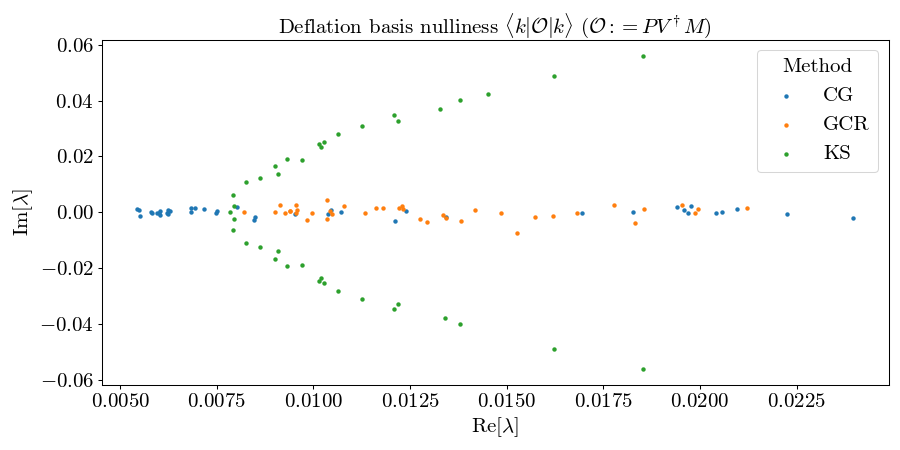

In [12]:
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(cg_null[0]), np.imag(cg_null[0]), ax = ax, col = pt.pal[0], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'CG')
pt.scatter_1d(np.real(gcr_null[0]), np.imag(gcr_null[0]), ax = ax, col = pt.pal[1], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'GCR')
pt.scatter_1d(np.real(pvdavm_evals), np.imag(pvdavm_evals), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'KS')
ax.legend(title = 'Method', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
ax.set_title(r'Deflation basis nulliness $\langle k | \mathcal{O} |k\rangle$ ($\mathcal{O} := PV^\dagger M$)', fontsize = default_style['fontsize'])
plt.tight_layout()

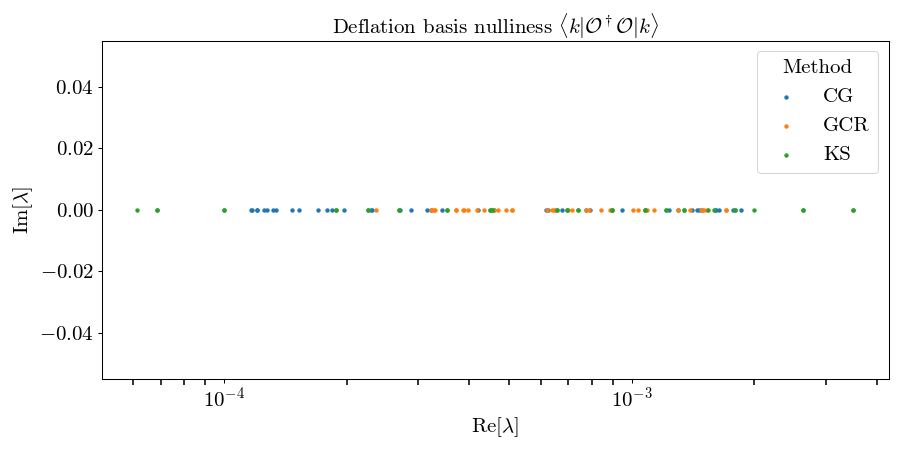

In [13]:
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(cg_null[1]), np.imag(cg_null[1]), ax = ax, col = pt.pal[0], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'CG')
pt.scatter_1d(np.real(gcr_null[1]), np.imag(gcr_null[1]), ax = ax, col = pt.pal[1], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'GCR')
pt.scatter_1d(np.abs(pvdavm_evals)**2, 0*np.imag(pvdavm_evals), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'KS')
ax.legend(title = 'Method', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
ax.set_title(r'Deflation basis nulliness $\langle k | \mathcal{O}^\dagger\mathcal{O} |k\rangle$', fontsize = default_style['fontsize'])
ax.set_xscale('log')
plt.tight_layout()

### Valence $m=0.001$

In [14]:
gcr_40_m0p001, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_341271.log')
ks_40_m0p001, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_341481.log')
cg_40_m0p001, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_341543.log')

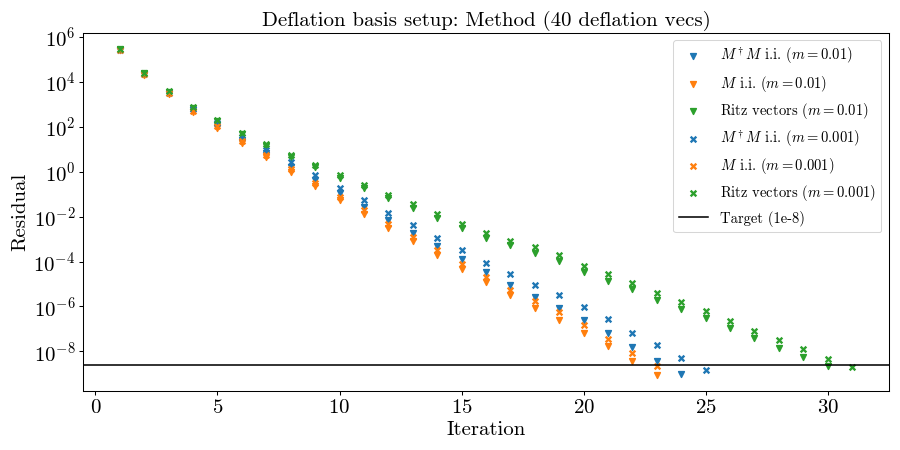

In [15]:
fig, axes = pt.add_subplots()
ax = axes[0]

pt.scatter_1d(np.arange(len(cg_40)) + 1, cg_40, ax = ax, col = pt.pal[0], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = r'$M^\dagger M$ i.i. ($m=0.01$)')
pt.scatter_1d(np.arange(len(gcr_40)) + 1, gcr_40, ax = ax, col = pt.pal[1], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = r'$M$ i.i. ($m=0.01$)')
pt.scatter_1d(np.arange(len(ks_40)) + 1, ks_40, ax = ax, col = pt.pal[2], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = r'Ritz vectors ($m=0.01$)')

pt.scatter_1d(np.arange(len(cg_40_m0p001)) + 1, cg_40_m0p001, ax = ax, col = pt.pal[0], mkr = 'x', ax_label = ['Iteration', 'Residual'], fn_label = r'$M^\dagger M$ i.i. ($m=0.001$)')
pt.scatter_1d(np.arange(len(gcr_40_m0p001)) + 1, gcr_40_m0p001, ax = ax, col = pt.pal[1], mkr = 'x', ax_label = ['Iteration', 'Residual'], fn_label = r'$M$ i.i. ($m=0.001$)')
pt.scatter_1d(np.arange(len(ks_40_m0p001)) + 1, ks_40_m0p001, ax = ax, col = pt.pal[2], mkr = 'x', ax_label = ['Iteration', 'Residual'], fn_label = r'Ritz vectors ($m=0.001$)')
# pt.scatter_1d(np.arange(len(hdcg_40_m0p001)) + 1, hdcg_40, ax = ax, col = pt.pal[3], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = 'HDCG(40)')

pt.add_line(ax, val = 2.5165824e-09, c = 'k', orientation = 'h', label = 'Target (1e-8)')

ax.set_title('Deflation basis setup: Method (40 deflation vecs)', fontsize = default_style['fontsize'])
ax.set_yscale('log')
ax.legend(fontsize = default_style['fontsize'] * 0.7, bbox_to_anchor = (1, 1))
plt.tight_layout()

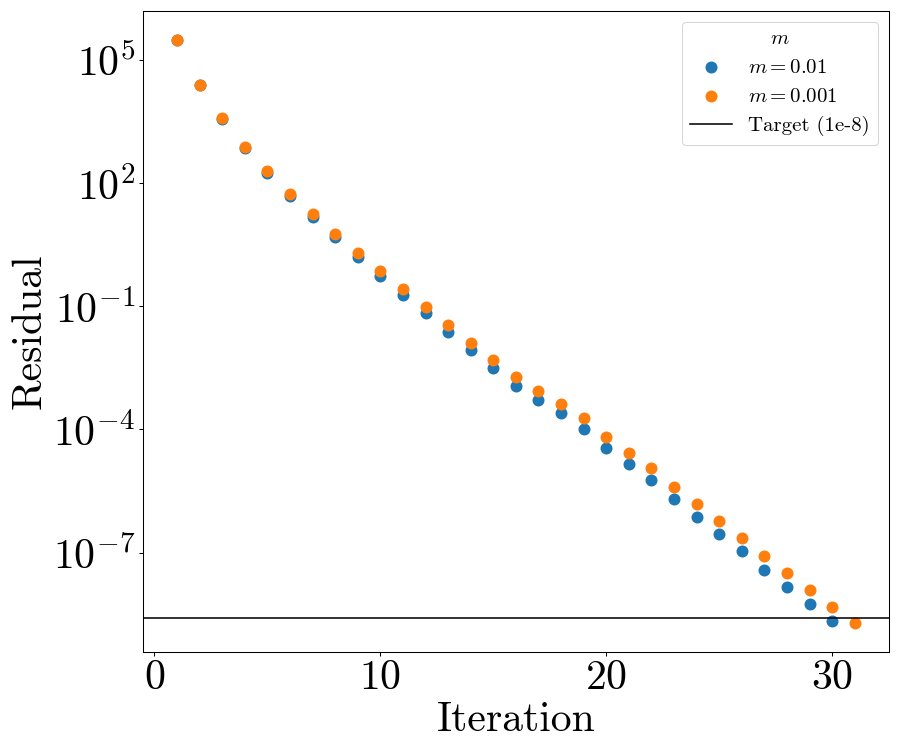

In [16]:
sty = default_style.copy()
sty['asp_ratio'] = 1.2
sty['markersize'] = 100
sty['fontsize'] = 40

fig, axes = pt.add_subplots(style = sty)
ax = axes[0]

pt.scatter_1d(np.arange(len(ks_40)) + 1, ks_40, ax = ax, col = pt.pal[0], mkr = 'o', ax_label = ['Iteration', 'Residual'], fn_label = r'$m=0.01$', style = sty)
pt.scatter_1d(np.arange(len(ks_40_m0p001)) + 1, ks_40_m0p001, ax = ax, col = pt.pal[1], mkr = 'o', ax_label = ['Iteration', 'Residual'], fn_label = r'$m=0.001$', style = sty)

pt.add_line(ax, val = 2.5165824e-09, c = 'k', orientation = 'h', label = 'Target (1e-8)')

ax.set_yscale('log')

ax.legend(title = r'$m$', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor = (1, 1))
plt.tight_layout()
# pt.save_figure('/Users/patrickoare/Dropbox (Personal)/research/multigrid/columbia_seminar/mg_iters.pdf')

In [17]:
cg_split = 'Running standard Krylov solve with GCR'
nomg_gcr_m0p001, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_343354.log', split_token=cg_split)
nomg_gcr_m0p01, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_343591.log', split_token=cg_split)

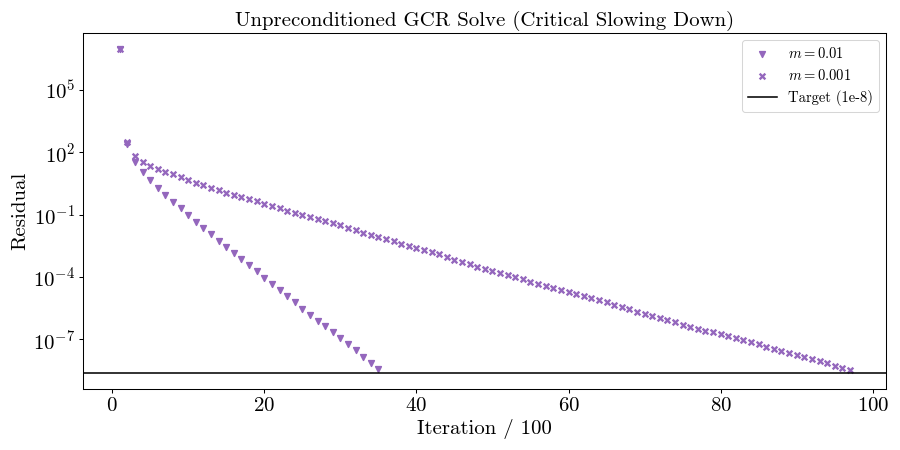

In [18]:
ITER_INC = 100

fig, axes = pt.add_subplots()
ax = axes[0]

pt.scatter_1d(np.arange(len(nomg_gcr_m0p01[::ITER_INC])) + 1, nomg_gcr_m0p01[::ITER_INC], ax = ax, col = pt.pal[4], mkr = 'v', ax_label = [f'Iteration / {ITER_INC}', 'Residual'], fn_label = r'$m=0.01$')
pt.scatter_1d(np.arange(len(nomg_gcr_m0p001[::ITER_INC])) + 1, nomg_gcr_m0p001[::ITER_INC], ax = ax, col = pt.pal[4], mkr = 'x', ax_label = [f'Iteration / {ITER_INC}', 'Residual'], fn_label = r'$m=0.001$')

pt.add_line(ax, val = 2.5165824e-09, c = 'k', orientation = 'h', label = 'Target (1e-8)')

ax.set_title('Unpreconditioned GCR Solve (Critical Slowing Down)', fontsize = default_style['fontsize'])
ax.set_yscale('log')
ax.legend(fontsize = default_style['fontsize'] * 0.7, bbox_to_anchor = (1, 1))
plt.tight_layout()

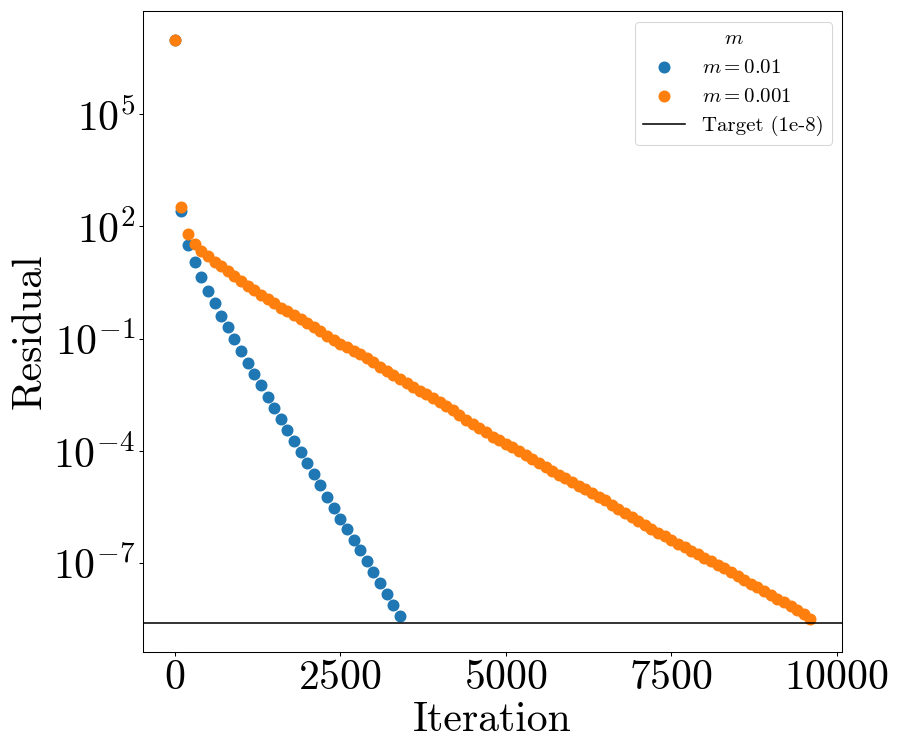

In [19]:
ITER_INC = 100
fig, axes = pt.add_subplots(style = sty)
ax = axes[0]

xx_0p01 = np.arange(len(nomg_gcr_m0p01)) + 1
xx_0p001 = np.arange(len(nomg_gcr_m0p001)) + 1

pt.scatter_1d(xx_0p01[::ITER_INC], nomg_gcr_m0p01[::ITER_INC], ax = ax, col = pt.pal[0], mkr = 'o', ax_label = [f'Iteration', 'Residual'], fn_label = r'$m=0.01$', style = sty)
pt.scatter_1d(xx_0p001[::ITER_INC], nomg_gcr_m0p001[::ITER_INC], ax = ax, col = pt.pal[1], mkr = 'o', ax_label = [f'Iteration', 'Residual'], fn_label = r'$m=0.001$', style = sty)

pt.add_line(ax, val = 2.5165824e-09, c = 'k', orientation = 'h', label = 'Target (1e-8)')

ax.set_yscale('log')

ax.legend(title = r'$m$', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor = (1, 1))
plt.tight_layout()
# pt.save_figure('/Users/patrickoare/Dropbox (Personal)/research/multigrid/columbia_seminar/krylov_iters.pdf')

In [20]:
pvdavm_evals_0p001 = parse_output(r"""(0.00271198013,6.07055638e-15)
 (0.00262057994,0.00245071107)
(0.00262057994,-0.00245071107)
 (0.00287796537,0.00635298344)
(0.00287796537,-0.00635298344)
  (0.00306203657,-0.011353517)
   (0.00306203657,0.011353517)
 (0.00346143194,-0.0127082208)
  (0.00346143194,0.0127082208)
  (0.00412778747,0.0141316872)
 (0.00412778161,-0.0141317154)
   (0.00385511873,0.016985985)
  (0.00385511873,-0.016985985)
  (0.00458972447,0.0194784355)
 (0.00458972208,-0.0194784375)
  (0.00412984347,0.0198108036)
 (0.00412984347,-0.0198108036)
  (0.00517118072,0.0243549209)
  (0.0051711862,-0.0243549251)
    (0.00495960844,0.02503961)
   (0.00495960844,-0.02503961)
   (0.00496185961,0.025960832)
  (0.00496185961,-0.025960832)
  (0.00533766677,0.0288537725)
 (0.00533766677,-0.0288537725)
 (0.00594038992,-0.0317450092)
  (0.00594038992,0.0317450092)
 (0.00693500035,-0.0337077683)
   (0.00693566504,0.033708518)
 (0.00673099163,-0.0357015812)
  (0.00673099163,0.0357015812)
  (0.00842381216,0.0412450961)
 (0.00842381098,-0.0412450968)
   (0.0091918213,0.0433509321)
  (0.00992204353,0.0456591561)
 (0.00957787344,-0.0457418386)
  (0.0107248078,-0.0501637747)
   (0.0107248078,0.0501637747)
   (0.0130583705,-0.057689828)
    (0.0130583705,0.057689828)""")

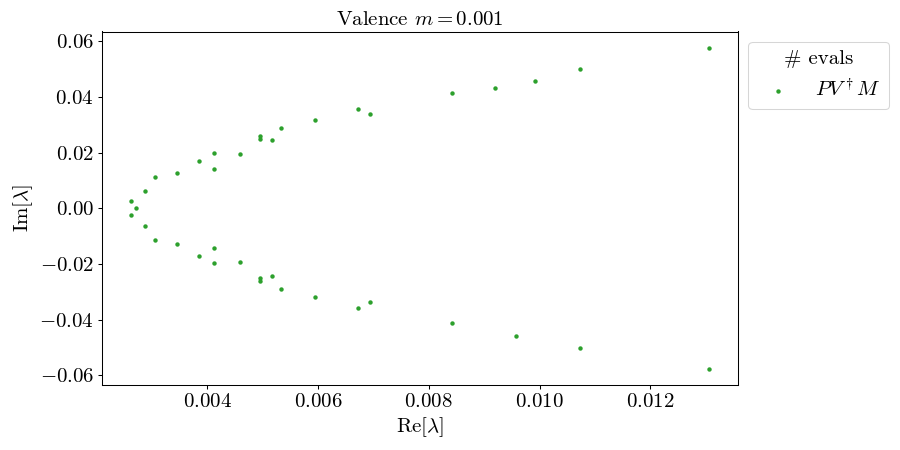

In [21]:
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(pvdavm_evals_0p001), np.imag(pvdavm_evals_0p001), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], title = r'Valence $m=0.001$', fn_label = r'$PV^\dagger M$')
ax.legend(title = r'# evals', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
plt.tight_layout()

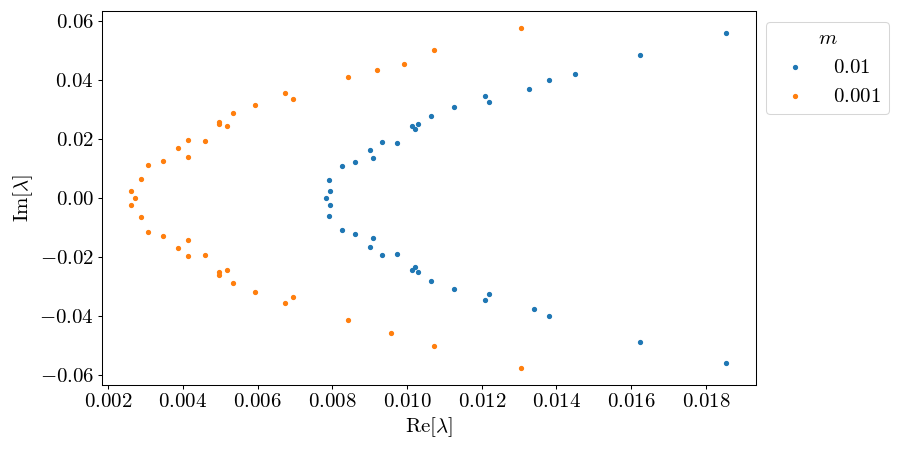

In [22]:
sty = default_style.copy()
sty['asp_ratio'] = 1.5
sty['markersize'] = 50

fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(pvdavm_evals), np.imag(pvdavm_evals), ax = ax, col = pt.pal[0], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'$0.01$', style = sty)
pt.scatter_1d(np.real(pvdavm_evals_0p001), np.imag(pvdavm_evals_0p001), ax = ax, col = pt.pal[1], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'$0.001$', style = sty)

ax.legend(title = r'$m$', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor = (1, 1))
plt.tight_layout()
# pt.save_figure('/Users/patrickoare/Dropbox (Personal)/research/multigrid/columbia_seminar/pvdagm_spectra.pdf')

In [23]:
gcr_null_m0p001 = read_nulliness('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_341271.log')
cg_null_m0p001 = read_nulliness('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_341543.log')
cg_null_m0p001_before_ortho = read_nulliness('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_341543.log', splitter = 'Before ortho=', second_split = None)

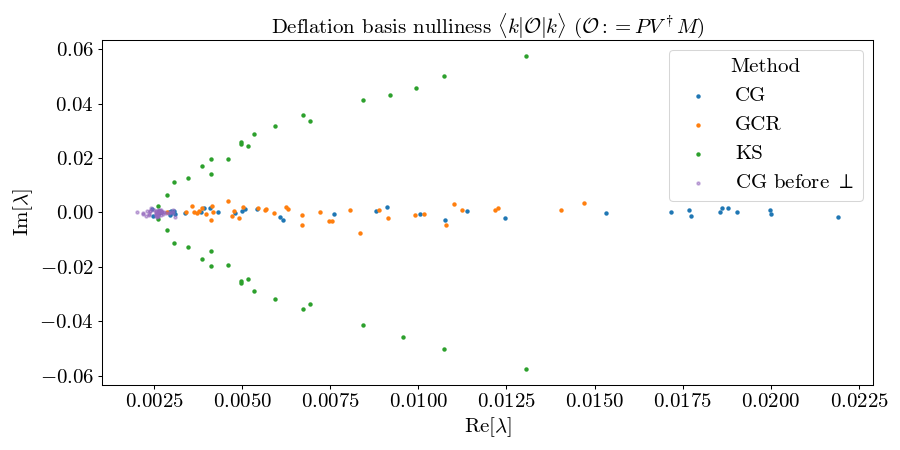

In [24]:
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(cg_null_m0p001[0]), np.imag(cg_null_m0p001[0]), ax = ax, col = pt.pal[0], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'CG')
pt.scatter_1d(np.real(gcr_null_m0p001[0]), np.imag(gcr_null_m0p001[0]), ax = ax, col = pt.pal[1], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'GCR', title = r'Valence $m=0.001$')
pt.scatter_1d(np.real(pvdavm_evals_0p001), np.imag(pvdavm_evals_0p001), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'KS', title = r'Valence $m=0.001$')

pt.scatter_1d(np.real(cg_null_m0p001_before_ortho[0]), np.imag(cg_null_m0p001_before_ortho[0]), ax = ax, col = pt.pal[4], alpha = 0.5, ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'CG before $\perp$')

ax.legend(title = 'Method', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
ax.set_title(r'Deflation basis nulliness $\langle k | \mathcal{O} |k\rangle$ ($\mathcal{O} := PV^\dagger M$)', fontsize = default_style['fontsize'])
plt.tight_layout()

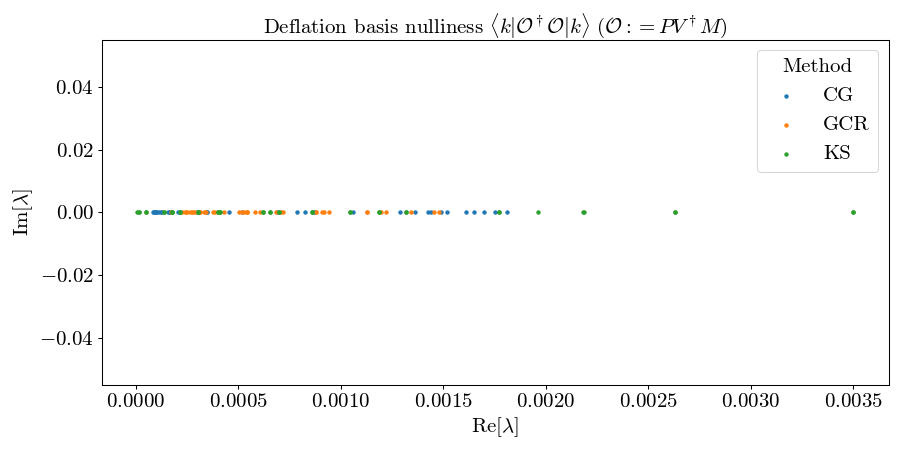

In [25]:
# TODO: need to update these using $\perp$ basis

fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(cg_null_m0p001[1]), np.imag(cg_null_m0p001[1]), ax = ax, col = pt.pal[0], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'CG')
pt.scatter_1d(np.real(gcr_null_m0p001[1]), np.imag(gcr_null_m0p001[1]), ax = ax, col = pt.pal[1], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'GCR', title = r'Valence $m=0.001$')
pt.scatter_1d(np.abs(pvdavm_evals_0p001)**2, np.imag(np.abs(pvdavm_evals_0p001)**2), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'KS', title = r'Valence $m=0.001$')

# pt.scatter_1d(np.abs(gcr_null_m0p001[0])**2, 0*np.imag(gcr_null_m0p001[1]), ax = ax, col = pt.pal[4], alpha = 0.5, ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'GCR $|\langle\mathcal{O}\rangle|^2', title = r'Valence $m=0.001$')

# pt.scatter_1d(np.real(cg_null_m0p001_before_ortho[0]), np.imag(cg_null_m0p001_before_ortho[0]), ax = ax, col = pt.pal[4], alpha = 0.5, ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'CG before $\perp$')

ax.legend(title = 'Method', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
ax.set_title(r'Deflation basis nulliness $\langle k | \mathcal{O}^\dagger \mathcal{O} |k\rangle$ ($\mathcal{O} := PV^\dagger M$)', fontsize = default_style['fontsize'])
plt.tight_layout()

## Mobius DWF with $PV^\dagger M$

In [26]:
mobius_pvdagm_evals_m0p001 = parse_output(r"""(0.00242234702,-2.20541827e-10)
 (0.00319877476,-0.00574077852)
  (0.00319877471,0.00574078023)
  (0.00405956046,-0.0131585042)
   (0.00405957829,0.0131585234)
  (0.00278173066,-0.0138780807)
   (0.00278173733,0.0138780838)
  (0.00434053436,-0.0226046825)
   (0.00434048727,0.0226047358)
   (0.00340496857,-0.024803274)
   (0.00340497123,0.0248033072)
   (0.00393897517,0.0276928163)
  (0.00393899638,-0.0276928257)
  (0.00458745095,-0.0307954489)
    (0.0045874394,0.0307954606)
   (0.00481108196,0.0370709566)
   (0.00481106809,-0.037070961)
  (0.00528729631,-0.0431873395)
   (0.00528724578,0.0431873997)
    (0.0105225688,0.0463090076)
   (0.0117198272,-0.0479350521)
   (0.00690988913,0.0535469606)
   (0.00690995021,-0.053547595)
  (0.00689750036,-0.0550734956)
   (0.00689758026,0.0550736883)
   (0.00712848287,0.0567019702)
  (0.00712857264,-0.0567019745)
   (0.00776639883,0.0632221223)
  (0.00776637958,-0.0632221977)
  (0.00881422952,-0.0694640511)
     (0.00881410403,0.06946414)
    (0.0100767534,0.0780925614)
   (0.0100766762,-0.0780926878)
    (0.0123907865,0.0865726502)
    (0.012973463,-0.0881196856)
    (0.0163522772,-0.109655876)
      (0.0163523332,0.10965587)
      (0.018972794,0.116563318)
     (0.0204907976,0.126757603)
    (0.0204905014,-0.126757759)""")

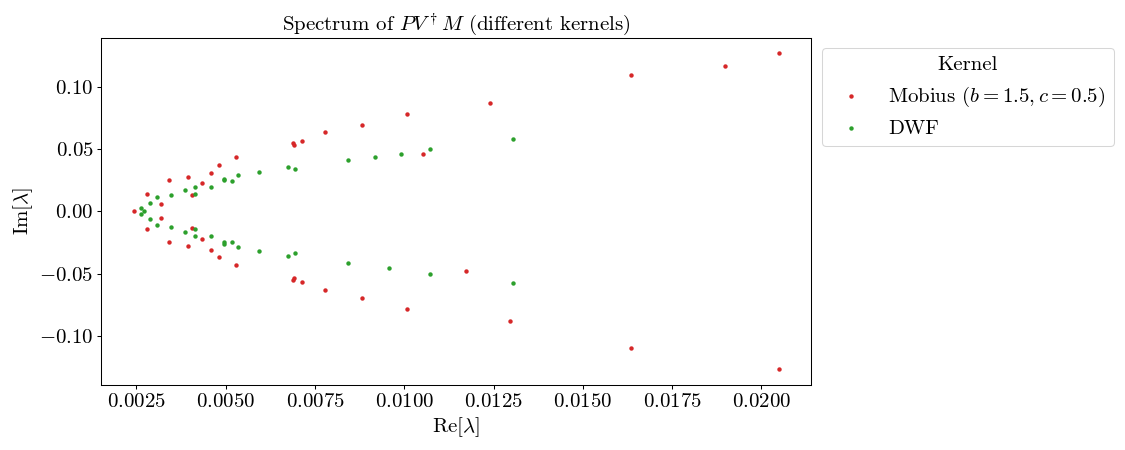

In [27]:
sty = default_style.copy()
sty['asp_ratio'] = 2.5
sty['colwidth'] = 15.0
fig, axes = pt.add_subplots(style = sty)
ax = axes[0]
pt.scatter_1d(np.real(mobius_pvdagm_evals_m0p001), np.imag(mobius_pvdagm_evals_m0p001), ax = ax, col = pt.pal[3], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'Mobius ($b=1.5,c=0.5$)', style = sty)
pt.scatter_1d(np.real(pvdavm_evals_0p001), np.imag(pvdavm_evals_0p001), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'DWF', style = sty)
# pt.add_line(ax, np.real(pvdavm_evals[20]), c = pt.pal[2], linestyle = '--')
ax.set_title(r'Spectrum of $PV^\dagger M$ (different kernels)', fontsize = default_style['fontsize'])
ax.legend(title = 'Kernel', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
plt.tight_layout()

- DWF: $m_{res} = 0.0092$.
- Mobius: $m_{res} = 0.0085$.

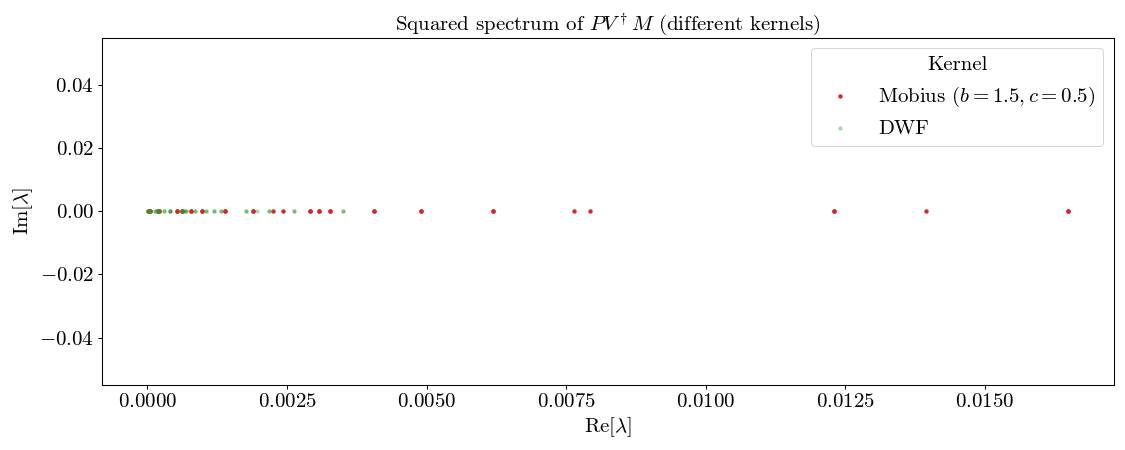

In [28]:
fig, axes = pt.add_subplots(style = sty)
ax = axes[0]
pt.scatter_1d(np.abs(mobius_pvdagm_evals_m0p001)**2, 0*np.imag(mobius_pvdagm_evals_m0p001), ax = ax, col = pt.pal[3], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'Mobius ($b=1.5,c=0.5$)', style = sty)
pt.scatter_1d(np.abs(pvdavm_evals_0p001)**2, 0*np.imag(pvdavm_evals_0p001), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], alpha = 0.3, fn_label = r'DWF', style = sty)
# pt.add_line(ax, np.real(pvdavm_evals[20]), c = pt.pal[2], linestyle = '--')
ax.set_title(r'Squared spectrum of $PV^\dagger M$ (different kernels)', fontsize = default_style['fontsize'])
ax.legend(title = 'Kernel', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
plt.tight_layout()

In [29]:
def parse_log_updated(file, header = 'Level 1 PGCR step[', split_token = 'Fine Grid Smoother -- Level 2'):
    run = -1
    tokens = [x.strip() for x in file.split('\n')]
    resids = [[], []]           # [[Cheby resids], [KS resids]]
    with open(file) as f:
        lines = f.readlines()
        for line in lines:
            # if split_token in line:
            # if '*** GCR setup ***' in line:
            #     run += 1
            # if '*** CG setup ***' in line:
            if split_token in line:
                run += 1
            if run < 0 or header not in line:
                continue
            resid = float(line.split('[')[1].split('resid ')[1].split(' target')[0])
            resids[run].append(resid)
    return resids

In [30]:
gcr_mobius_m0p001, cg_mobius_m0p001 = parse_log_updated('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_346850.log', split_token = 'CoarsenMatrixColoured vec 0/40')

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/var/folders/4q/v1ykxzz94sn6ms0kkh0gm8880000gr/T/ipykernel_32917/2241314657.py:3: SyntaxWarning: invalid escape sequence '\d'
  pt.scatter_1d(np.arange(len(cg_mobius_m0p001)) + 1, cg_mobius_m0p001, ax = ax, col = pt.pal[0], ax_label = ['Iteration', 'Residual'], fn_label = '$M^\dagger M$ i.i. (40)')
/var/folders/4q/v1ykxzz94sn6ms0kkh0gm8880000gr/T/ipykernel_32917/2241314657.py:9: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title('Mobius kernel, $PV^\dagger M$ setup with 40 deflation vectors', fontsize = default_style['fontsize'])


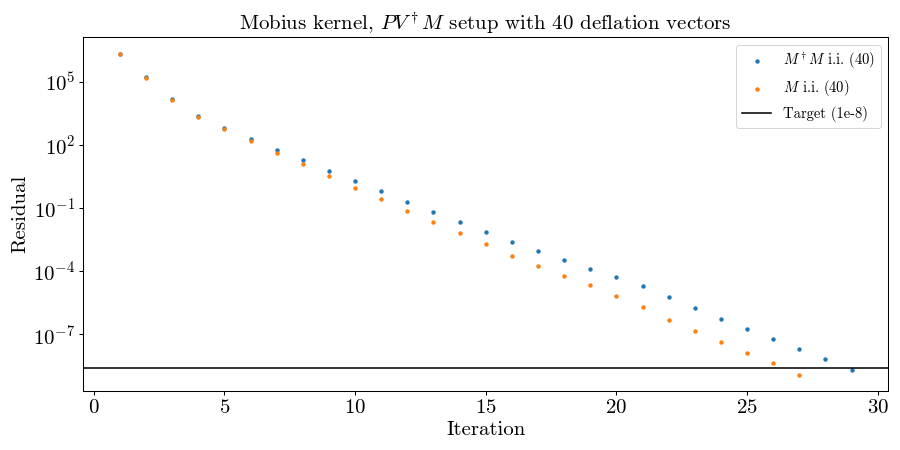

In [31]:
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.arange(len(cg_mobius_m0p001)) + 1, cg_mobius_m0p001, ax = ax, col = pt.pal[0], ax_label = ['Iteration', 'Residual'], fn_label = '$M^\dagger M$ i.i. (40)')
pt.scatter_1d(np.arange(len(gcr_mobius_m0p001)) + 1, gcr_mobius_m0p001, ax = ax, col = pt.pal[1], ax_label = ['Iteration', 'Residual'], fn_label = '$M$ i.i. (40)')
# pt.scatter_1d(np.arange(len(ks_20)) + 1, ks_20, ax = ax, col = pt.pal[2], ax_label = ['Iteration', 'Residual'], fn_label = 'Ritz vectors (20)')

pt.add_line(ax, val = 2.5165824e-09, c = 'k', orientation = 'h', label = 'Target (1e-8)')

ax.set_title('Mobius kernel, $PV^\dagger M$ setup with 40 deflation vectors', fontsize = default_style['fontsize'])
ax.set_yscale('log')
ax.legend(fontsize = default_style['fontsize'] * 0.7, bbox_to_anchor = (1, 1))
plt.tight_layout()

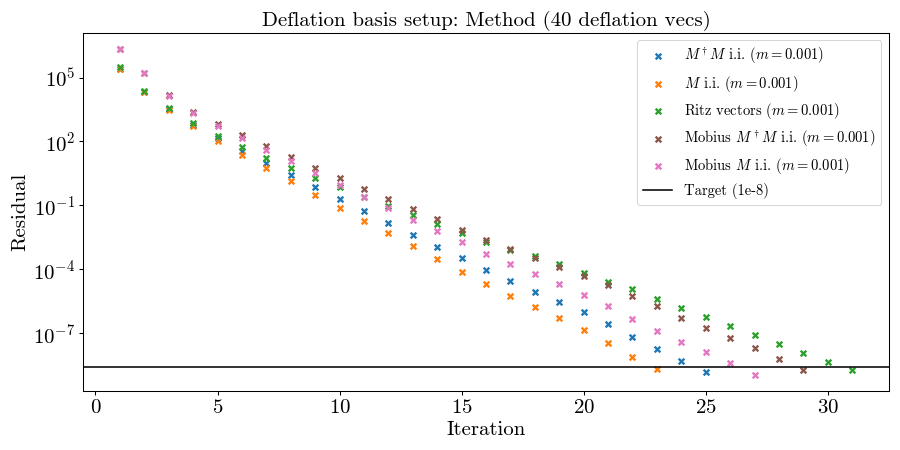

In [32]:
fig, axes = pt.add_subplots()
ax = axes[0]

pt.scatter_1d(np.arange(len(cg_40_m0p001)) + 1, cg_40_m0p001, ax = ax, col = pt.pal[0], mkr = 'x', ax_label = ['Iteration', 'Residual'], fn_label = r'$M^\dagger M$ i.i. ($m=0.001$)')
pt.scatter_1d(np.arange(len(gcr_40_m0p001)) + 1, gcr_40_m0p001, ax = ax, col = pt.pal[1], mkr = 'x', ax_label = ['Iteration', 'Residual'], fn_label = r'$M$ i.i. ($m=0.001$)')
pt.scatter_1d(np.arange(len(ks_40_m0p001)) + 1, ks_40_m0p001, ax = ax, col = pt.pal[2], mkr = 'x', ax_label = ['Iteration', 'Residual'], fn_label = r'Ritz vectors ($m=0.001$)')
# pt.scatter_1d(np.arange(len(hdcg_40_m0p001)) + 1, hdcg_40, ax = ax, col = pt.pal[3], mkr = 'v', ax_label = ['Iteration', 'Residual'], fn_label = 'HDCG(40)')

pt.scatter_1d(np.arange(len(cg_mobius_m0p001)) + 1, cg_mobius_m0p001, ax = ax, col = pt.pal[5], mkr = 'x', ax_label = ['Iteration', 'Residual'], fn_label = r'Mobius $M^\dagger M$ i.i. ($m=0.001$)')
pt.scatter_1d(np.arange(len(gcr_mobius_m0p001)) + 1, gcr_mobius_m0p001, ax = ax, col = pt.pal[6], mkr = 'x', ax_label = ['Iteration', 'Residual'], fn_label = r'Mobius $M$ i.i. ($m=0.001$)')

pt.add_line(ax, val = 2.5165824e-09, c = 'k', orientation = 'h', label = 'Target (1e-8)')

ax.set_title('Deflation basis setup: Method (40 deflation vecs)', fontsize = default_style['fontsize'])
ax.set_yscale('log')
ax.legend(fontsize = default_style['fontsize'] * 0.7, bbox_to_anchor = (1, 1))
plt.tight_layout()

Run standard Krylov solve with the Shamir kernel too-- likely will see much slower than DWF kernel 

In [33]:
# read off nulliness for GCR
def read_nulliness_updated(file, splitter = '<i|D|i>=', second_split = '; <i|DdagD|i>='):
    tokens = [x.strip() for x in file.split('\n')]
    nulliness = [
        [[], []],           # [[<O>], [<O^\dagger O>]]
        [[], []],
    ]
    idx = -1
    # nulliness = []
    with open(file) as f:
        lines = f.readlines()
        for token in lines:
            if 'Orthonormalizing basis and computing nulliness' in token:
                idx += 1
                continue
            if splitter in token:
                if second_split:
                    O, Osq = token.split(splitter)[1].split(second_split)
                    tmp = O[1:-1].split(',')
                    nulliness[idx][0].append(float(tmp[0]) + 1j*float(tmp[1]))
                    nulliness[idx][1].append(float(Osq))
                else:
                    O = token.split(splitter)[1]
                    tmp = O[1:-2].split(',')
                    nulliness[idx][0].append(float(tmp[0]) + 1j*float(tmp[1]))
    return nulliness
# gcr_null, gcr_nullsq = read_nulliness('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_340843.log')
gcr_mobius_null, cg_mobius_null = read_nulliness_updated('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_346850.log')

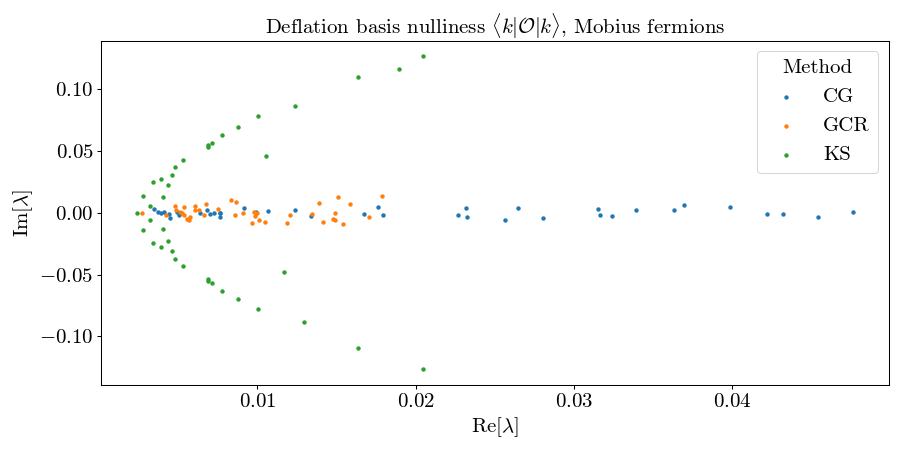

In [34]:
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(cg_mobius_null[0]), np.imag(cg_mobius_null[0]), ax = ax, col = pt.pal[0], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'CG')
pt.scatter_1d(np.real(gcr_mobius_null[0]), np.imag(gcr_mobius_null[0]), ax = ax, col = pt.pal[1], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'GCR', title = r'Valence $m=0.001$')
pt.scatter_1d(np.real(mobius_pvdagm_evals_m0p001), np.imag(mobius_pvdagm_evals_m0p001), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'KS', title = r'Valence $m=0.001$')

# pt.scatter_1d(np.real(cg_null_m0p001_before_ortho[0]), np.imag(cg_null_m0p001_before_ortho[0]), ax = ax, col = pt.pal[4], alpha = 0.5, ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'CG before $\perp$')

ax.legend(title = 'Method', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
ax.set_title(r'Deflation basis nulliness $\langle k | \mathcal{O} |k\rangle$, Mobius fermions', fontsize = default_style['fontsize'])
plt.tight_layout()

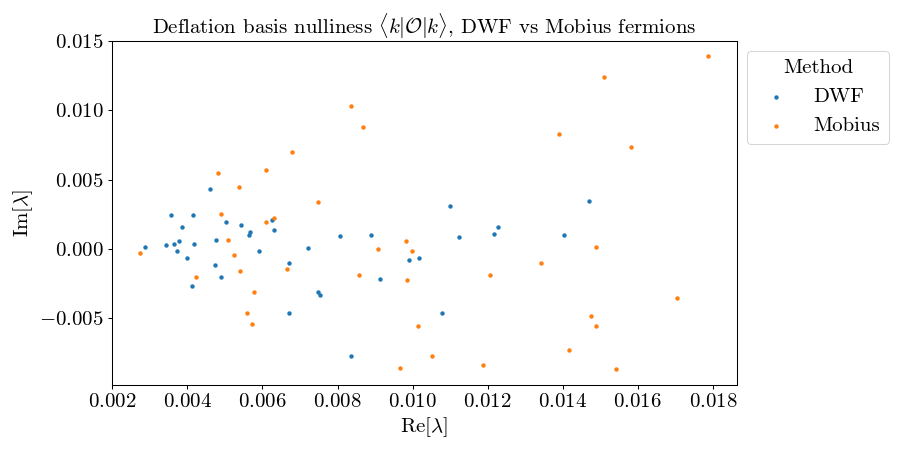

In [35]:
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(gcr_null_m0p001[0]), np.imag(gcr_null_m0p001[0]), ax = ax, col = pt.pal[0], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'DWF')
pt.scatter_1d(np.real(gcr_mobius_null[0]), np.imag(gcr_mobius_null[0]), ax = ax, col = pt.pal[1], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'Mobius')

ax.legend(title = 'Method', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
ax.set_title(r'Deflation basis nulliness $\langle k | \mathcal{O} |k\rangle$, DWF vs Mobius fermions', fontsize = default_style['fontsize'])
plt.tight_layout()

In [36]:
cg_split = 'Running standard Krylov solve with GCR'
mobius_gcr_m0p001, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_347085.log', split_token=cg_split)

/Users/patrickoare/lqcd/utilities/plottools.py:79: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(nrows = n_rows, ncols = n_cols, figsize = [n_cols * fig_size[0], n_rows * fig_size[1]])


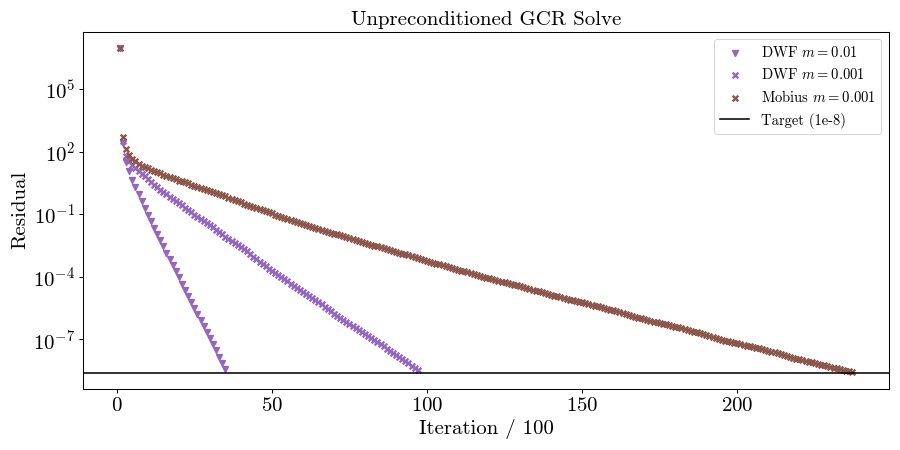

In [37]:
ITER_INC = 100

fig, axes = pt.add_subplots()
ax = axes[0]

pt.scatter_1d(np.arange(len(nomg_gcr_m0p01[::ITER_INC])) + 1, nomg_gcr_m0p01[::ITER_INC], ax = ax, col = pt.pal[4], mkr = 'v', ax_label = [f'Iteration / {ITER_INC}', 'Residual'], fn_label = r'DWF $m=0.01$')
pt.scatter_1d(np.arange(len(nomg_gcr_m0p001[::ITER_INC])) + 1, nomg_gcr_m0p001[::ITER_INC], ax = ax, col = pt.pal[4], mkr = 'x', ax_label = [f'Iteration / {ITER_INC}', 'Residual'], fn_label = r'DWF $m=0.001$')

pt.scatter_1d(np.arange(len(mobius_gcr_m0p001[::ITER_INC])) + 1, mobius_gcr_m0p001[::ITER_INC], ax = ax, col = pt.pal[5], mkr = 'x', ax_label = [f'Iteration / {ITER_INC}', 'Residual'], fn_label = r'Mobius $m=0.001$')

pt.add_line(ax, val = 2.5165824e-09, c = 'k', orientation = 'h', label = 'Target (1e-8)')

ax.set_title('Unpreconditioned GCR Solve', fontsize = default_style['fontsize'])
ax.set_yscale('log')
ax.legend(fontsize = default_style['fontsize'] * 0.7, bbox_to_anchor = (1, 1))
plt.tight_layout()

## $m_\mathrm{res}$ calculation

Compute $m_\mathrm{res}$ by computing the quotient $\langle P J_{5q} \rangle / \langle PP \rangle$ and fitting the resulting quotient to a constant over the lattice size. Note that the previous RBC/UKQCD work computed this at $L_s = 24$. 

In [38]:
def parse_mres_corr(file, split_token = 'Axial Ward identity by timeslice', header = ' PJ5q '):
    mres = []
    with open(file) as f:
        lines = f.readlines()
        for line in lines:
            if split_token in line:
                mres.append([])
            if header not in line:
                continue
            tokens = line.split(' PJ5q ')
            pp = float(tokens[0].split(' PP ')[1])
            pJ5q = float(tokens[1].split(' Ward')[0])
            print(f'PP = {pp}, PJ5q = {pJ5q}')
            mres[-1].append(pJ5q / pp)
    return np.array(mres)

TODO: accidentally ran with $m=0.01$ for the $Ls=24$, running with $m=0.001$ on job 348883. Will need to redownload the `mres_0p001.log` file once it's done

In [39]:
dwf_mres, mobius_mres, _ = parse_mres_corr('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/mres_0p001.log')
dwf_mres_24, mobius_mres_24, _, shamir_mres_24 = parse_mres_corr('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/mres_0p001_Ls24.log')
# dwf_mres, mobius_mres, _, _ = parse_mres_corr('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/mres_0p001_hot.log')
# dwf_mres_24, mobius_mres_24, _, shamir_mres_24 = parse_mres_corr('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/mres_0p001_Ls24_hot.log')

PP = 0.567498358, PJ5q = 0.000292144864
PP = 0.222258519, PJ5q = 0.000238272955
PP = 0.0613834528, PJ5q = 0.000177569956
PP = 0.0299072571, PJ5q = 0.000100268765
PP = 0.0178039595, PJ5q = 5.36330923e-05
PP = 0.0121116629, PJ5q = 6.8373117e-05
PP = 0.00885123994, PJ5q = 8.68914588e-05
PP = 0.00594363233, PJ5q = 3.81228575e-05
PP = 0.00402861732, PJ5q = 1.44670518e-05
PP = 0.00284462126, PJ5q = 1.04300918e-05
PP = 0.00208917514, PJ5q = 7.41511333e-06
PP = 0.00172021171, PJ5q = 1.7740456e-05
PP = 0.00156504558, PJ5q = 2.22344053e-05
PP = 0.001378547, PJ5q = 1.00341224e-05
PP = 0.0012303503, PJ5q = 4.26485106e-06
PP = 0.00115981436, PJ5q = 2.99664958e-06
PP = 0.00111908033, PJ5q = 2.19162142e-06
PP = 0.001203827, PJ5q = 2.13443098e-06
PP = 0.00142044305, PJ5q = 2.73907285e-06
PP = 0.00182896163, PJ5q = 4.89054033e-06
PP = 0.00247771752, PJ5q = 1.03373514e-05
PP = 0.00326976454, PJ5q = 1.10434271e-05
PP = 0.00433679133, PJ5q = 1.00432588e-05
PP = 0.00575617739, PJ5q = 1.14406229e-05
PP = 0.

In [40]:
dwf_mres_0p01, mobius_mres_0p01, _ = parse_mres_corr('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/mres_0p01.log')

PP = 0.567498358, PJ5q = 0.000292144864
PP = 0.222258519, PJ5q = 0.000238272955
PP = 0.0613834528, PJ5q = 0.000177569956
PP = 0.0299072571, PJ5q = 0.000100268765
PP = 0.0178039595, PJ5q = 5.36330923e-05
PP = 0.0121116629, PJ5q = 6.8373117e-05
PP = 0.00885123994, PJ5q = 8.68914588e-05
PP = 0.00594363233, PJ5q = 3.81228575e-05
PP = 0.00402861732, PJ5q = 1.44670518e-05
PP = 0.00284462126, PJ5q = 1.04300918e-05
PP = 0.00208917514, PJ5q = 7.41511333e-06
PP = 0.00172021171, PJ5q = 1.7740456e-05
PP = 0.00156504558, PJ5q = 2.22344053e-05
PP = 0.001378547, PJ5q = 1.00341224e-05
PP = 0.0012303503, PJ5q = 4.26485106e-06
PP = 0.00115981436, PJ5q = 2.99664958e-06
PP = 0.00111908033, PJ5q = 2.19162142e-06
PP = 0.001203827, PJ5q = 2.13443098e-06
PP = 0.00142044305, PJ5q = 2.73907285e-06
PP = 0.00182896163, PJ5q = 4.89054033e-06
PP = 0.00247771752, PJ5q = 1.03373514e-05
PP = 0.00326976454, PJ5q = 1.10434271e-05
PP = 0.00433679133, PJ5q = 1.00432588e-05
PP = 0.00575617739, PJ5q = 1.14406229e-05
PP = 0.

In [41]:
mres_paper = gv.gvar('0.003102(25)')

# range_0p01 = np.union1d(np.arange(2, 5), np.union1d(np.arange(8, 11), np.arange(15, 30)))
# range_0p01 = np.union1d(np.arange(2, 5), np.union1d(np.arange(8, 11), [14, 20]))
# range_0p01 = np.union1d(np.arange(2, 5), np.union1d(np.arange(8, 11), np.arange(15, 25)))
range_0p01 = np.arange(2, 5)
# range_0p01 = np.arange(2, 30)

def get_bounds(dat, rng = np.arange(15, 30)):
    xplus = np.max(dat[rng])
    xminus = np.min(dat[rng])
    return gv.gvar((xplus+xminus) / 2, (xplus-xminus) / 2)

# m_dwf_0p01 = gv.gvar(
#     np.mean(dwf_mres_0p01[range_0p01]),
#     np.std(dwf_mres_0p01[range_0p01])
# )
# m_mobius_0p01 = gv.gvar(
#     np.mean(mobius_mres_0p01[range_0p01]),
#     np.std(mobius_mres_0p01[range_0p01])
# )
m_dwf_0p01 = get_bounds(dwf_mres_0p01)
m_mobius_0p01 = get_bounds(mobius_mres_0p01)

m_dwf_16 = gv.gvar(
    np.mean(dwf_mres[range_0p01]),
    np.std(dwf_mres[range_0p01])
)
m_mobius_16 = gv.gvar(
    np.mean(mobius_mres[range_0p01]),
    np.std(mobius_mres[range_0p01])
)
m_dwf_24 = gv.gvar(
    np.mean(dwf_mres_24[15:]),
    np.std(dwf_mres_24[15:])
)
m_mobius_24 = gv.gvar(
    np.mean(mobius_mres_24[15:]),
    np.std(mobius_mres_24[15:])
)

In [42]:
def make_errband(ax, dat, y, col, label = None):
    # xx = np.arange(len(dat))
    xx = [-1, 33]
    upper = (gv.mean(y) + gv.sdev(y)) * np.ones(len(xx))
    lower = (gv.mean(y) - gv.sdev(y)) * np.ones(len(xx))
    ax.fill_between(xx, lower, upper, color = col, alpha = 0.1, label = label)

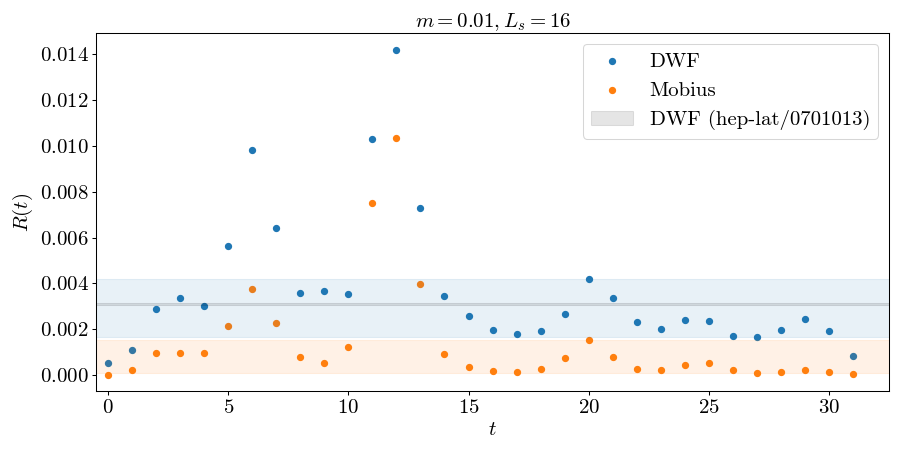

In [43]:
fig, axes = pt.add_subplots()
ax = axes[0]

pt.scatter_1d(range(len(dwf_mres_0p01)), dwf_mres_0p01, ax = ax, col = pt.pal[0], mkr = 'o', ax_label = [r'$t$', r'$R(t)$'], fn_label = 'DWF')
pt.scatter_1d(range(len(mobius_mres_0p01)), mobius_mres_0p01, ax = ax, col = pt.pal[1], mkr = 'o', ax_label = [r'$t$', r'$R(t)$'], fn_label = 'Mobius')

make_errband(ax, dwf_mres_0p01, m_dwf_0p01, col = pt.pal[0])
make_errband(ax, mobius_mres_0p01, m_mobius_0p01, col = pt.pal[1])

make_errband(ax, dwf_mres_0p01, mres_paper, col = 'k', label = 'DWF (hep-lat/0701013)')

# ax.set_yscale('log')
ax.set_xlim((-0.5, 32.5))

ax.set_title(r'$m=0.01, L_s = 16$', fontsize = default_style['fontsize'])
ax.legend(fontsize = default_style['fontsize'])
plt.tight_layout()

In [44]:
print(f'DWF mres (m 0.01) = {m_dwf_0p01}.')
print(f'Mobius mres (m 0.01) = {m_mobius_0p01}.')

DWF mres (m 0.01) = 0.0029(13).
Mobius mres (m 0.01) = 0.00080(71).


This roughly agrees with what we expect from https://arxiv.org/abs/hep-lat/0701013? Table VI has $m_{res} = 0.003102(25)$, which lies neatly in this band

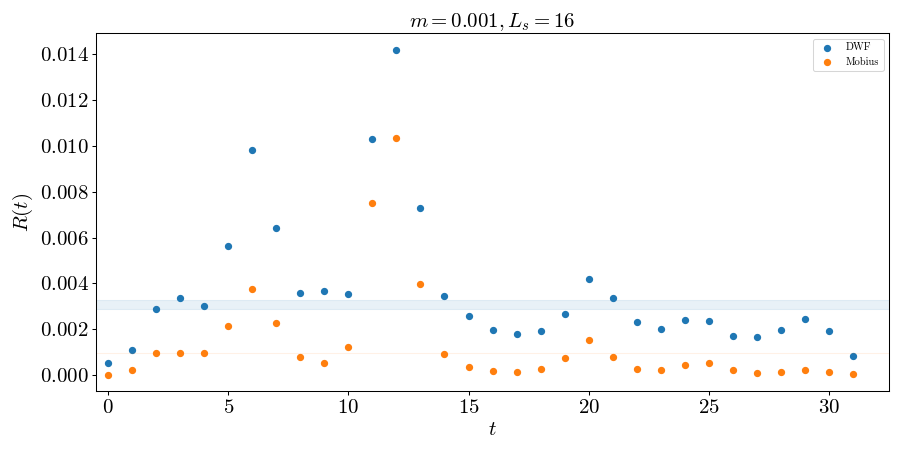

In [45]:
fig, axes = pt.add_subplots()
ax = axes[0]

pt.scatter_1d(range(len(dwf_mres)), dwf_mres, ax = ax, col = pt.pal[0], mkr = 'o', ax_label = [r'$t$', r'$R(t)$'], fn_label = 'DWF')
pt.scatter_1d(range(len(mobius_mres)), mobius_mres, ax = ax, col = pt.pal[1], mkr = 'o', ax_label = [r'$t$', r'$R(t)$'], fn_label = 'Mobius')

make_errband(ax, dwf_mres, m_dwf_16, col = pt.pal[0])
make_errband(ax, mobius_mres, m_mobius_16, col = pt.pal[1])

# ax.set_yscale('log')
ax.set_xlim((-0.5, 32.5))

ax.set_title(r'$m=0.001, L_s = 16$', fontsize = default_style['fontsize'])
ax.legend()
plt.tight_layout()

In [46]:
print(f'DWF mres (Ls 16) = {m_dwf_16}.')
print(f'Mobius mres (Ls 16) = {m_mobius_16}.')

DWF mres (Ls 16) = 0.00309(19).
Mobius mres (Ls 16) = 0.0009687(35).


In [47]:
# dwf_mres_meff = eff_mass(dwf_mres)
# mobius_mres_meff = eff_mass(mobius_mres)

# fig, axes = pt.add_subplots()
# ax = axes[0]

# pt.scatter_1d(range(len(dwf_mres_meff)), dwf_mres_meff, ax = ax, col = pt.pal[0], mkr = 'o', ax_label = [r'$t$', r'$m_{eff}(t)$'], fn_label = 'DWF')
# pt.scatter_1d(range(len(mobius_mres_meff)), mobius_mres_meff, ax = ax, col = pt.pal[1], mkr = 'o', ax_label = [r'$t$', r'$m_{eff}(t)$'], fn_label = 'Mobius')

# ax.set_yscale('log')

# ax.set_title(r'$m_\mathrm{res}$', fontsize = default_style['fontsize'])
# ax.legend()

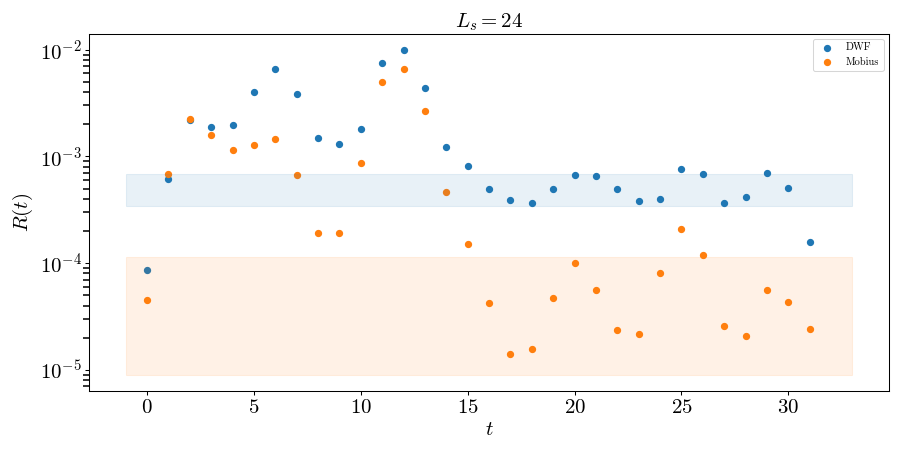

In [48]:
fig, axes = pt.add_subplots()
ax = axes[0]

pt.scatter_1d(range(len(dwf_mres_24)), dwf_mres_24, ax = ax, col = pt.pal[0], mkr = 'o', ax_label = [r'$t$', r'$R(t)$'], fn_label = 'DWF')
pt.scatter_1d(range(len(mobius_mres_24)), mobius_mres_24, ax = ax, col = pt.pal[1], mkr = 'o', ax_label = [r'$t$', r'$R(t)$'], fn_label = 'Mobius')
# pt.scatter_1d(range(len(shamir_mres_24)), shamir_mres_24, ax = ax, col = pt.pal[2], mkr = 'x', ax_label = [r'$t$', r'$R(t)$'], fn_label = 'Shamir')

make_errband(ax, dwf_mres_24, m_dwf_24, col = pt.pal[0])
make_errband(ax, mobius_mres_24, m_mobius_24, col = pt.pal[1])

ax.set_title(r'$L_s = 24$', fontsize = default_style['fontsize'])
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

In [49]:
print(f'DWF mres (Ls 24) = {m_dwf_24}.')
print(f'Mobius mres (Ls 24) = {m_mobius_24}.')

DWF mres (Ls 24) = 0.00051(17).
Mobius mres (Ls 24) = 6.2(5.3)e-05.
